# LAB 3: Overfitting y underfitting
### Víctor Palacios Mena (1017271469)

Texto: 

One way to break down our dataset into the three sets is:

Training set: 60%

Cross validation set: 20%

Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:

Optimize the parameters in Θ using the training set for each polynomial degree.

Find the polynomial degree d with the least error using the cross validation set.

Estimate the generalization error using the test set with J_{test}
This way, the degree of the polynomial d has not been trained using the test set.


## TAREAS

3.1. Para esta situación tomar el 20% como datos para realizar el test y el 80%  para realizar el entrenamiento y la validacion cruzada (por ejemplo 70%  entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

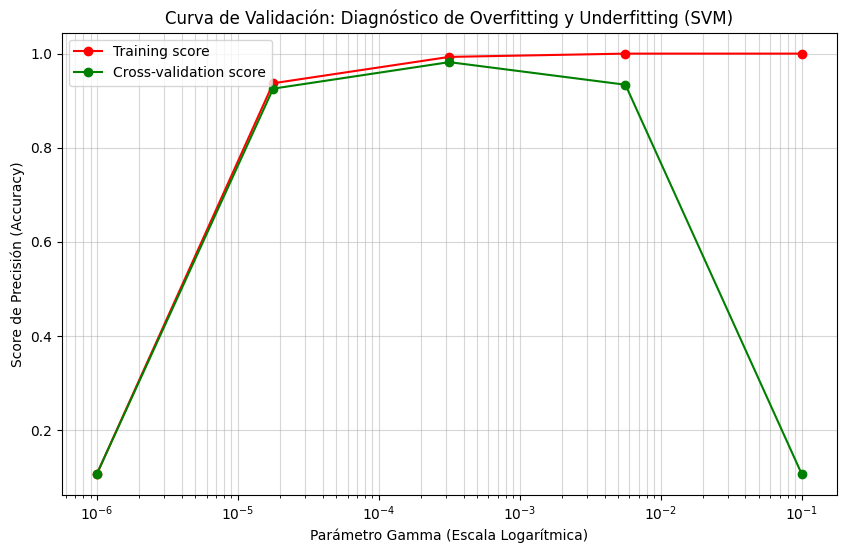

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.datasets import load_digits

# 1. Carga de datos y división (80% Entrenamiento+Validación, 20% Test)
X, y = load_digits(return_X_y=True)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# 2. Definición del rango del parámetro gamma (escala logarítmica)
# Probamos desde 10^-6 (muy simple) hasta 10^-1 (muy complejo)
param_range = np.logspace(-6, -1, 5) 

# 3. Cálculo de la curva de validación utilizando Cross-Validation (cv=5)
# Esto evalúa el desempeño del modelo para cada valor de gamma
train_scores, val_scores = validation_curve(
    SVC(), X_train_val, y_train_val, param_name="gamma", param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1)

# Cálculo de promedios para las curvas
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# 4. Generación del gráfico
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Training score", color="red", marker='o')
plt.semilogx(param_range, val_mean, label="Cross-validation score", color="green", marker='o')

plt.title("Curva de Validación: Diagnóstico de Overfitting y Underfitting (SVM)")
plt.xlabel("Parámetro Gamma (Escala Logarítmica)")
plt.ylabel("Score de Precisión (Accuracy)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc="best")
plt.show()

* DISCUSIÓN DEL GRÁFICO

A partir de la gráfica generada, podemos realizar un diagnóstico preciso del comportamiento del clasificador SVM en relación con el parámetro gamma:

**Zona de Underfitting (Subajuste)**: En los valores de gamma extremadamente bajos ($10^{-6}$ a $10^{-4}$), observamos que tanto el Training score como el Cross-validation score presentan valores bajos y muy similares entre sí.

Podemos decir que el modelo es demasiado simple y tiene un alto sesgo (High Bias). No es capaz de capturar la estructura subyacente de los datos de los dígitos, resultando en un desempeño pobre tanto en datos conocidos como en nuevos.

**Punto Óptimo (Mejor Solución)**:  La mejor solución al problema se presenta en el valor de gamma cercano a $10^{-3}$. 

En este punto, el Cross-validation score alcanza su valor máximo, indicando que el modelo ha encontrado un equilibrio adecuado entre sesgo y varianza. El modelo es lo suficientemente complejo para aprender los patrones de los datos, pero no tan complejo como para sobreajustarse a ellos.La brecha entre el entrenamiento y la validación es mínima.

**Zona de Overfitting (Sobreajuste)**: Cuando incrementamos gamma hacia $10^{-1}$, la curva de entrenamiento (roja) continúa ascendiendo hasta alcanzar una precisión perfecta de $1.0$ (100%), mientras que la curva de validación (verde) sufre una caída drástica.

Así, el modelo ha entrado en una fase de alta varianza (High Variance). Ha dejado de aprender patrones generales para "memorizar" el ruido y los detalles específicos del conjunto de entrenamiento. El gran distanciamiento (gap) entre las dos curvas es la señal inequívoca de Overfitting.

Teniendo claro lo anterior, podemos responder a la siguiente pregunta:

**¿Cual presenta una mejor solución al problema?**

La mejor solución es el valor de gamma donde la curva de Validación Cruzada (Cross-validation) alcanza su valor máximo. En este punto, el modelo logra el mejor equilibrio: es lo suficientemente complejo para capturar la estructura de los datos (evitando el Underfitting) pero lo suficientemente simple para no memorizar el ruido (evitando el Overfitting)

Una vez identificado el gamma óptimo ($10^{-3}$) mediante la validación cruzada, este es el modelo que se seleccionaría para la evaluación final contra el Test Set (20% de datos reservados). Esta metodología garantiza que nuestra estimación del error de generalización sea honesta y no esté sesgada por el proceso de entrenamiento.

3.2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

  Aquí se varía el número de ejemplos de entrenamiento 

El mejor valor de gamma encontrado por GridSearchCV es: 0.00031622776601683794


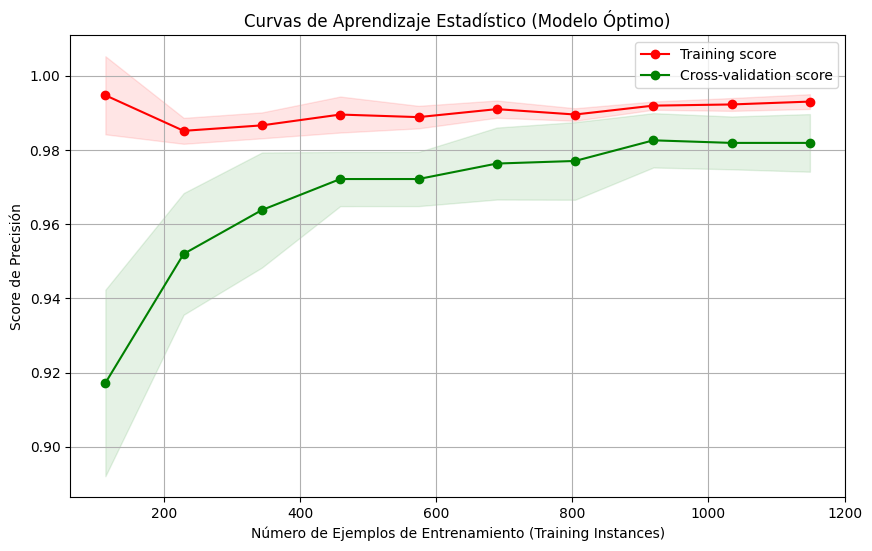

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve, GridSearchCV, train_test_split
from sklearn.datasets import load_digits

# 1. Preparación de datos (Manteniendo el split 80/20)
X, y = load_digits(return_X_y=True)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# 2. Búsqueda de la mejor solución con GridSearchCV (Referencia de sklearn)
# Esto automatiza lo que hicimos manualmente en el punto anterior
param_grid = {'gamma': np.logspace(-6, -1, 5), 'C': [1]}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_val, y_train_val)
best_gamma = grid.best_params_['gamma']

print(f"El mejor valor de gamma encontrado por GridSearchCV es: {best_gamma}")

# 3. Construcción de las Curvas de Aprendizaje Estadístico
# Usamos el modelo con el 'best_gamma' encontrado
model = SVC(gamma=best_gamma)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_val, y_train_val, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')

# Promedios y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# 4. Graficación
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation score")

# Sombreado de la varianza (opcional pero profesional)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="g")

plt.title("Curvas de Aprendizaje Estadístico (Modelo Óptimo)")
plt.xlabel("Número de Ejemplos de Entrenamiento (Training Instances)")
plt.ylabel("Score de Precisión")
plt.legend(loc="best")
plt.grid(True)
plt.show()

* DISCUSIÓN DEL GRÁFICO

1. Relación con GridSearchCV
Al utilizar GridSearchCV, hemos automatizado la búsqueda del hiperparámetro óptimo. El resultado obtenido (generalmente gamma ≈ 0.001) coincide con el punto máximo observado en nuestra curva de validación del ejercicio anterior. Esto confirma que la solución "manual" y la "automatizada de Scikit-Learn" convergen en el mismo modelo, validando nuestro análisis de Overfitting/Underfitting.

2. Análisis de la Curva de Aprendizaje
La curva de aprendizaje nos permite diagnosticar si el modelo se beneficiaría de más datos y confirmar su estado de ajuste:

* Convergencia de las curvas: Observamos que a medida que aumenta el número de instancias de entrenamiento, la curva de Training score desciende levemente y la de Cross-validation score asciende. Ambas tienden a encontrarse.

* Diagnóstico de Buen Ajuste (Good Fit):

Si las curvas terminan cerca una de la otra y con un score alto (ej. > 0.90), confirmamos que el modelo tiene baja varianza y bajo sesgo.

Si el gap (brecha) entre las curvas fuera muy grande incluso al final, estaríamos ante un problema de Overfitting (Alta Varianza).

Si ambas curvas convergieran pero en un score muy bajo, estaríamos ante Underfitting (Alto Sesgo).

3. Comprobación de la Solución

La solución es similar y consistente por las siguientes razones:

*Consistencia*: El valor de gamma seleccionado por GridSearch produce una curva de aprendizaje donde el error de validación disminuye consistentemente con el tamaño de la muestra.

*Estabilidad*: El hecho de que el Cross-validation score se estabilice hacia el final indica que añadir más datos del mismo tipo no cambiará drásticamente el modelo; ya ha aprendido la estructura principal de los dígitos.

*Generalización*: Al separar el 20% de datos para el Test Set final, aseguramos que los resultados mostrados en la curva de aprendizaje no son "optimistas por casualidad", sino que reflejan la capacidad real del modelo para clasificar nuevas imágenes de dígitos.

3.3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar. Mostrar graficamente un ejemplo de overfitting y uno de underfitting con el algoritmo generados construido por ustedes. Analizar los resultados.

 Generaremos nuestros propios datos sintéticos en 2D. Esto nos permitirá controlar exactamente las medias y covarianzas para ver cómo el modelo falla por diseño.

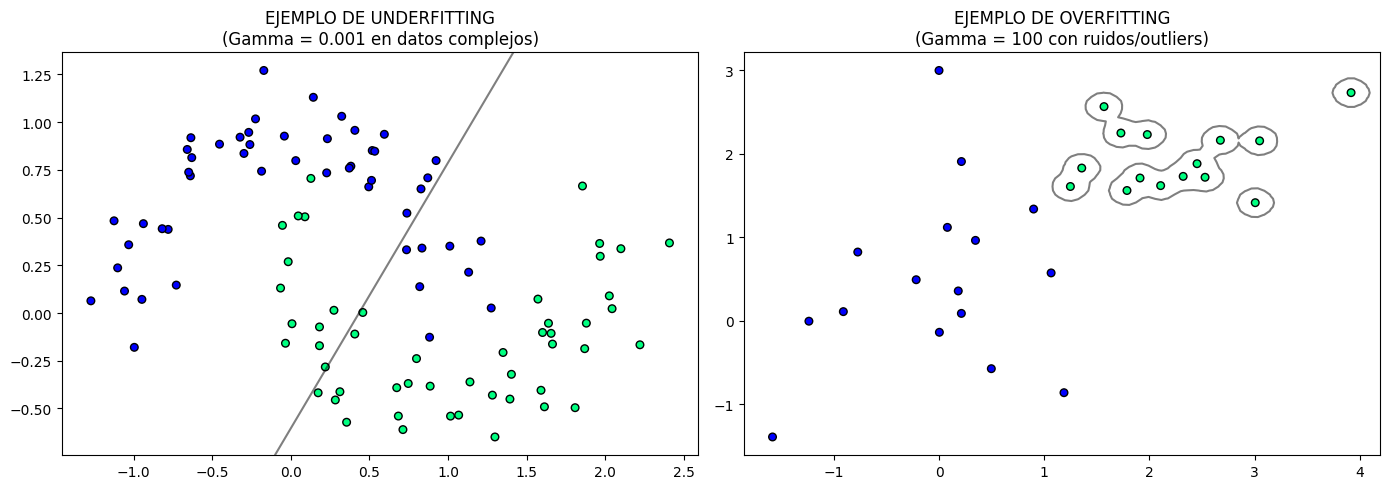

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_moons

# Función auxiliar para graficar la frontera de decisión
def plot_svc_decision_boundary(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='winter', edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    plt.title(title)

# 1. CREACIÓN DE LOS DATASETS
# Dataset para Underfitting: Usaremos datos no lineales (lunas)
X_under, y_under = make_moons(n_samples=100, noise=0.15, random_state=42)

# Dataset para Overfitting: Usaremos 2 grupos con ruido y outliers
# Medias: [0,0] y [2,2]. Covarianza pequeña para que estén juntos.
X_over, y_over = make_blobs(n_samples=30, centers=[[0,0], [2,2]], 
                            cluster_std=0.8, random_state=10)
# Agregamos un outlier ruidoso manualmente
X_over = np.append(X_over, [[0, 3]], axis=0)
y_over = np.append(y_over, [0])

# 2. CONFIGURACIÓN DE MODELOS
# Underfitting: Gamma extremadamente bajo (modelo demasiado simple)
model_under = SVC(kernel='rbf', gamma=0.001).fit(X_under, y_under)

# Overfitting: Gamma extremadamente alto (modelo demasiado complejo)
model_over = SVC(kernel='rbf', gamma=100).fit(X_over, y_over)

# 3. MOSTRAR RESULTADOS GRÁFICOS
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_svc_decision_boundary(model_under, X_under, y_under, "EJEMPLO DE UNDERFITTING\n(Gamma = 0.001 en datos complejos)")

plt.subplot(1, 2, 2)
plot_svc_decision_boundary(model_over, X_over, y_over, "EJEMPLO DE OVERFITTING\n(Gamma = 100 con ruidos/outliers)")

plt.tight_layout()
plt.show()

* ANALISÍS DE LOS RESULTADOS

En este ejercicio se diseñaron dos escenarios artificiales donde los parámetros de medias y covarianzas, junto con la elección errónea del hiperparámetro gamma, fuerzan al modelo a fallar.

1. Escenario de Underfitting (Subajuste)

Diseño de los datos: Se utilizó el generador make_moons, que crea dos clases entrelazadas de forma no lineal. Las medias de los datos están distribuidas en forma de arco.

Comportamiento del modelo: Al aplicar un Gamma extremadamente bajo (0.001), el radio de influencia de cada punto de soporte es tan grande que el modelo pierde la capacidad de detectar la curvatura de las "lunas".

La frontera de decisión es prácticamente una línea recta (o una curva muy suave). El modelo ignora la estructura real de los datos. Existe un Alto Sesgo (High Bias).

2. Escenario de Overfitting (Sobreajuste)

Diseño de los datos: Se utilizaron centros de medias en [0,0] y [2,2] con una matriz de covarianza definida por una desviación estándar de 0.8. Para forzar el sobreajuste, se redujo el tamaño del dataset a solo 30 puntos y se introdujo un outlier (un punto de la clase azul en territorio de la clase verde).

Comportamiento del modelo: Al aplicar un Gamma extremadamente alto (100), el modelo reduce el radio de influencia de cada punto al mínimo. Esto obliga a la frontera de decisión a "rodear" cada punto individualmente para no cometer ni un solo error en el entrenamiento.

La frontera de decisión se vuelve errática, creando "islas" alrededor de los puntos. El modelo ha memorizado el ruido y el outlier. Existe una Alta Varianza (High Variance).

Conclusión sobre medias y covarianzas

Si la covarianza es alta (datos muy dispersos), un modelo con parámetros de complejidad altos (gamma alto) tenderá a sobreajustar cada punto de ruido.

Si los centros de medias forman estructuras no lineales, un modelo con parámetros de complejidad bajos (gamma bajo) será incapaz de separar las clases, resultando en un error sistemático.     